# Attention Map Analysis

This notebook continues after `parcel_by_modality_attn_atlas.py`. It assumes the script has already produced `parcel_modality_attn_norm.npy`, `parcel_modality_attn_raw.npy`, `metadata.json`, `quality_control.json`, and `query_to_parcel.npy` under `attn_map_analysis/results/<subject>/<run_name>/`.

Main analyses:
1. Parcel modality atlas: token-count-normalized modality attention, modality fractions, winner maps, entropy/selectivity.
2. Yeo/Schaefer ROI summaries: network-level modality profiles and hemisphere/network tables.
3. Cross-subject reliability: subject-to-subject correlations for each modality/preference map.
4. Brain visualization: write continuous selectivity maps and categorical modality-preference labels back into subject Schaefer atlas volumes.


In [234]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm
import nibabel as nib
from nilearn import plotting
import seaborn as sns

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            print("Adding font:", font)
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")

import matplotlib as mpl
mpl.rcParams.update({
    # Make math consistent if present
    "mathtext.fontset": "dejavusans",
    # Axis text
    "axes.labelsize": 28,
    "axes.titlesize": 30,
    # Tick labels
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 24,
})
sns.set_theme(style="whitegrid", context="paper")

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != "multimodal_encoder":
    # Adjust this if you launch Jupyter from a different working directory.
    REPO_ROOT = Path("/engram/nklab/pf2477/multimodal_encoder")

RESULT_ROOT = REPO_ROOT / "attn_map_analysis" / "results"
FIGURE_ROOT = REPO_ROOT / "attn_map_analysis" / "figures"
TABLE_ROOT = REPO_ROOT / "attn_map_analysis" / "tables"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

# Parcel-level runs from the current atlas extraction.
RUNS = (
    (1, "04-07-2026-16-09", "dino_whisper_llama", "parcels"),
    (2, "04-07-2026-16-13", "dino_whisper_llama", "parcels"),
    (3, "04-08-2026-00-52", "dino_whisper_llama", "parcels"),
    (5, "04-08-2026-00-55", "dino_whisper_llama", "parcels"),

    (1, "04-08-2026-23-43", "dino_whisper_llama", "voxels"),
    (2, "04-08-2026-23-48", "dino_whisper_llama", "voxels"),
    (3, "04-08-2026-23-57", "dino_whisper_llama", "voxels"),
    (5, "04-12-2026-19-49", "dino_whisper_llama", "voxels"),

    (1, "04-18-2026-01-08", "videmae_wav2vec_deberta", "parcels"),
    (2, "04-18-2026-01-14", "videmae_wav2vec_deberta", "parcels"),
    (3, "04-18-2026-22-20", "videmae_wav2vec_deberta", "parcels"),
    (5, "04-18-2026-22-22",  "videmae_wav2vec_deberta", "parcels"),

    (1, "04-19-2026-02-08", "videmae_wav2vec_deberta", "voxels"),
    (2, "04-19-2026-02-10", "videmae_wav2vec_deberta", "voxels"),
    (3, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
    (5, "04-20-2026-00-29",  "videmae_wav2vec_deberta", "voxels"),
)


MODALITY_COLORS = {
    "video": "#43A3EF",
    "audio": "#EF767B",
    "text": "#F4BA05",
}

# Top-token fraction used by modality preference/selectivity maps.
PREFERENCE_TOP_TOKEN_FRACTION = 0.25

print("repo:", REPO_ROOT)
print("result root exists:", RESULT_ROOT.exists())


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf
repo: /engram/nklab/pf2477/multimodal_encoder
result root exists: True


## Load Atlas Outputs

`parcel_modality_attn_norm` is the primary map because it divides each modality attention mass by the number of memory tokens for that modality. The raw mass is still loaded for QC and secondary plots.

In [236]:
def load_json(path):
    with Path(path).open("r") as f:
        return json.load(f)


def normalized_entropy(p, axis=-1, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = p / np.clip(p.sum(axis=axis, keepdims=True), eps, None)
    ent = -(p * np.log(np.clip(p, eps, None))).sum(axis=axis)
    return ent / np.log(p.shape[axis])


def top_token_fraction_suffix(fraction):
    percent = 100.0 * float(fraction)
    if np.isclose(percent, round(percent)):
        return f"top{int(round(percent)):02d}pct"
    compact = f"{float(fraction):.6g}".replace(".", "p")
    return f"frac{compact}"


def normalize_run_specs(run_specs):
    if isinstance(run_specs, dict):
        for subject_id, run_name in run_specs.items():
            yield {
                "subject_id": int(subject_id),
                "run_name": str(run_name),
                "backbones": "unknown",
                "readout": "unknown",
            }
        return

    for spec in run_specs:
        if isinstance(spec, dict):
            yield {
                "subject_id": int(spec["subject_id"]),
                "run_name": str(spec["run_name"]),
                "backbones": str(spec.get("backbones", spec.get("backbone", "unknown"))),
                "readout": str(spec.get("readout", "unknown")),
            }
        else:
            if len(spec) != 4:
                raise ValueError(f"Expected RUNS entries as (subject_id, run_name, backbones, readout), got {spec}")
            subject_id, run_name, backbones, readout = spec
            yield {
                "subject_id": int(subject_id),
                "run_name": str(run_name),
                "backbones": str(backbones),
                "readout": str(readout),
            }


def make_run_key(subject_id, run_name, backbones, readout):
    return f"sub-{int(subject_id):02d}_{backbones}_{readout}_{run_name}"


def load_run(subject_id, run_name, backbones="unknown", readout="unknown"):
    run_dir = RESULT_ROOT / str(subject_id) / run_name
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    metadata = load_json(run_dir / "metadata.json")
    qc = load_json(run_dir / "quality_control.json")
    modalities = list(metadata["modalities"])
    run_key = make_run_key(subject_id, run_name, backbones, readout)

    norm = np.load(run_dir / "parcel_modality_attn_norm.npy")
    raw = np.load(run_dir / "parcel_modality_attn_raw.npy")
    query_to_parcel = np.load(run_dir / "query_to_parcel.npy")

    preference_top_token_fraction = float(globals().get("PREFERENCE_TOP_TOKEN_FRACTION", 0.25))
    preference_top_token_suffix = top_token_fraction_suffix(preference_top_token_fraction)
    top_token_mean_path = run_dir / f"parcel_modality_attn_top_token_mean_{preference_top_token_suffix}.npy"
    top_token_fraction_path = run_dir / f"parcel_modality_attn_top_token_fraction_{preference_top_token_suffix}.npy"
    top_token_source = preference_top_token_suffix
    if not top_token_mean_path.exists() or not top_token_fraction_path.exists():
        top_token_mean_path = run_dir / "parcel_modality_attn_top_token_mean.npy"
        top_token_fraction_path = run_dir / "parcel_modality_attn_top_token_fraction.npy"
        top_token_source = "primary_alias"
    top_token_mean = np.load(top_token_mean_path) if top_token_mean_path.exists() else None
    top_token_fraction = np.load(top_token_fraction_path) if top_token_fraction_path.exists() else None

    norm_fraction = norm / np.clip(norm.sum(axis=1, keepdims=True), 1e-12, None)
    raw_fraction = raw / np.clip(raw.sum(axis=1, keepdims=True), 1e-12, None)
    preference_fraction = top_token_fraction if top_token_fraction is not None else norm_fraction
    preference_score_source = (
        f"top_token_fraction_{top_token_source}"
        if top_token_fraction is not None
        else "modality_sum_fraction"
    )
    winner_index = preference_fraction.argmax(axis=1).astype(int)
    sorted_fraction = np.sort(preference_fraction, axis=1)
    entropy = normalized_entropy(preference_fraction)

    parcel_df = pd.DataFrame({
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "parcel_id": query_to_parcel.astype(int),
        "winner_code": winner_index,
        "winner_modality": [modalities[i] for i in winner_index],
        "winner_margin": sorted_fraction[:, -1] - sorted_fraction[:, -2],
        "modality_entropy": entropy,
        "modality_selectivity": 1.0 - entropy,
    })

    for i, modality in enumerate(modalities):
        parcel_df[f"{modality}_norm"] = norm[:, i]
        parcel_df[f"{modality}_raw"] = raw[:, i]
        parcel_df[f"{modality}_fraction"] = norm_fraction[:, i]
        parcel_df[f"{modality}_raw_fraction"] = raw_fraction[:, i]
        parcel_df[f"{modality}_centered"] = norm_fraction[:, i] - norm_fraction.mean(axis=1)

        baseline = norm_fraction[:, i].mean()
        centered = norm_fraction[:, i] - baseline
        parcel_df[f"relative_{modality}_centered"] = np.where(
            centered >= 0,
            100 * centered / np.clip(1.0 - baseline, 1e-12, None),
            100 * centered / np.clip(baseline, 1e-12, None),
        )

    return {
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "run_dir": run_dir,
        "metadata": metadata,
        "qc": qc,
        "modalities": modalities,
        "norm": norm,
        "raw": raw,
        "norm_fraction": norm_fraction,
        "raw_fraction": raw_fraction,
        "top_token_mean": top_token_mean,
        "top_token_fraction": top_token_fraction,
        "preference_fraction": preference_fraction,
        "preference_score_source": preference_score_source,
        "query_to_parcel": query_to_parcel,
        "parcel_df": parcel_df,
    }


run_specs = list(normalize_run_specs(RUNS))
run_list = [load_run(**spec) for spec in run_specs]
runs = {run["run_key"]: run for run in run_list}
runs_by_subject = {}
for run in run_list:
    runs_by_subject.setdefault(run["subject_id"], []).append(run["run_key"])

DEFAULT_RUN_KEY = run_list[0]["run_key"]
parcel_df = pd.concat([run["parcel_df"] for run in run_list], ignore_index=True)

run_summary = pd.DataFrame([
    {
        "run_key": run["run_key"],
        "subject_id": run["subject_id"],
        "run_name": run["run_name"],
        "backbones": run["backbones"],
        "readout": run["readout"],
        "samples": run["qc"]["num_samples_analyzed"],
        "queries": run["metadata"]["num_queries"],
        "attention_head_aggregation": run["metadata"].get("attention_head_aggregation", "unknown"),
        "preference_score_source": run["preference_score_source"],
        "top_token_fraction": run["metadata"].get("top_token_preference", {}).get(
            "primary_top_token_fraction",
            run["metadata"].get("top_token_preference", {}).get("top_token_fraction", np.nan),
        ),
        "attn_sum_max_abs_error": run["qc"]["attn_sum_axis_last_max_abs_error"],
        "qc_ok": run["qc"]["attn_sum_axis_last_within_tolerance"],
    }
    for run in run_list
])

display(parcel_df.head())
display(run_summary)


,run_key,subject_id,run_name,backbones,readout,parcel_id,winner_code,winner_modality,winner_margin,modality_entropy,...,audio_fraction,audio_raw_fraction,audio_centered,relative_audio_centered,text_norm,text_raw,text_fraction,text_raw_fraction,text_centered,relative_text_centered
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,1,1,audio,0.265992,0.936017,...,0.495755,0.435364,0.162421,-11.888949,0.000142,0.072856,0.243053,0.072856,-0.090281,5.254178
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,2,1,audio,0.262849,0.914013,...,0.517533,0.421186,0.184200,-8.018183,0.000097,0.049803,0.179285,0.049803,-0.154049,-10.837206
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,3,1,audio,0.326494,0.863622,...,0.558093,0.451399,0.224759,-0.809510,0.000081,0.041225,0.149322,0.041225,-0.184011,-25.738272
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4,1,audio,0.194333,0.898712,...,0.497636,0.375705,0.164303,-11.554493,0.000070,0.035762,0.138774,0.035762,-0.194559,-30.984150
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,5,1,audio,0.226780,0.889903,...,0.493901,0.377861,0.160567,-12.218469,0.000077,0.039385,0.150821,0.039385,-0.182512,-24.992836


,run_key,subject_id,run_name,backbones,readout,samples,queries,attention_head_aggregation,preference_score_source,top_token_fraction,attn_sum_max_abs_error,qc_ok
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000069,True
1,sub-02_dino_whisper_llama_parcels_04-07-2026-1...,2,04-07-2026-16-13,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000133,True
2,sub-03_dino_whisper_llama_parcels_04-08-2026-0...,3,04-08-2026-00-52,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000060,True
3,sub-05_dino_whisper_llama_parcels_04-08-2026-0...,5,04-08-2026-00-55,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000076,True
4,sub-01_dino_whisper_llama_voxels_04-08-2026-23-43,1,04-08-2026-23-43,dino_whisper_llama,voxels,4875,1000,mean,top_token_fraction_top25pct,0.25,0.000088,True
5,sub-02_dino_whisper_llama_voxels_04-08-2026-23-48,2,04-08-2026-23-48,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,0.25,0.000094,True
6,sub-03_dino_whisper_llama_voxels_04-08-2026-23-57,3,04-08-2026-23-57,dino_whisper_llama,voxels,4871,1000,mean,top_token_fraction_top25pct,0.25,0.000085,True
7,sub-05_dino_whisper_llama_voxels_04-12-2026-19-49,5,04-12-2026-19-49,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,0.25,0.000086,True
8,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000089,True
9,sub-02_videmae_wav2vec_deberta_parcels_04-18-2...,2,04-18-2026-01-14,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000126,True


                         count      mean       std       min       25%  \
modality stability_type                                                  
audio    Backbone          8.0  0.192939  0.098400  0.022904  0.137325   
         Readout           8.0  0.674412  0.080494  0.552611  0.632924   
         Subject          24.0  0.644898  0.103460  0.449213  0.589529   
text     Backbone          8.0  0.305407  0.107165  0.143907  0.236787   
         Readout           8.0  0.673036  0.078101  0.563689  0.614796   
         Subject          24.0  0.616465  0.054634  0.502082  0.584309   
video    Backbone          8.0  0.755359  0.074854  0.634647  0.709882   
         Readout           8.0  0.775163  0.039065  0.716873  0.753627   
         Subject          24.0  0.748335  0.052704  0.654220  0.717166   

                              50%       75%       max  
modality stability_type                                
audio    Backbone        0.201073  0.242034  0.338933  
         Readout 

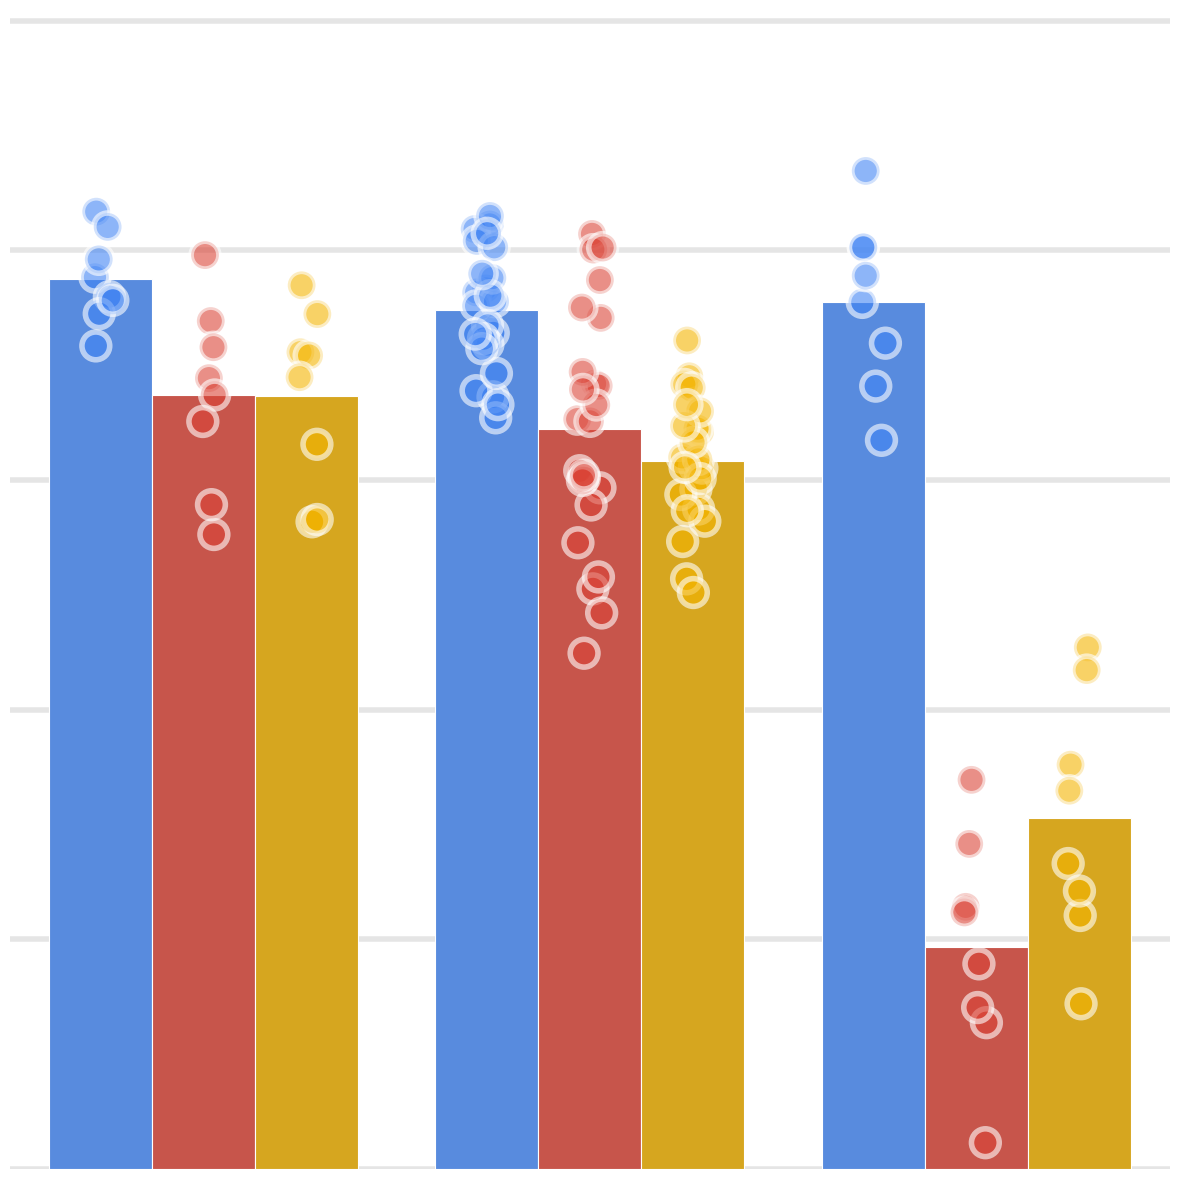

In [174]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SUBJECTS = [1, 2, 3, 5]
BACKBONES = ["dino_whisper_llama", "videmae_wav2vec_deberta"]
READOUTS = ["parcels", "voxels"]
MODALITIES = ["video", "audio", "text"]

runs_dict = {
    (subject, backbone, readout): run_name
    for subject, run_name, backbone, readout in RUNS
}

def get_vec(subject, backbone, readout, modality):
    run = load_run(subject, runs_dict[(subject, backbone, readout)])
    return run["parcel_df"][f"relative_{modality}_centered"].to_numpy()

records = []

for modality in MODALITIES:

    # 1. Readout stability: same subject, same backbone, parcel vs voxel
    for subject in SUBJECTS:
        for backbone in BACKBONES:
            x = get_vec(subject, backbone, "parcels", modality)
            y = get_vec(subject, backbone, "voxels", modality)
            rho, _ = spearmanr(x, y)
            records.append({
                "modality": modality,
                "stability_type": "Readout",
                "spearman_rho": rho,
                "comparison": f"sub-{subject}, {backbone}",
            })

    # 2. Subject stability: same backbone, same readout, subject pairs
    for backbone in BACKBONES:
        for readout in READOUTS:
            for s1, s2 in itertools.combinations(SUBJECTS, 2):
                x = get_vec(s1, backbone, readout, modality)
                y = get_vec(s2, backbone, readout, modality)
                rho, _ = spearmanr(x, y)
                records.append({
                    "modality": modality,
                    "stability_type": "Subject",
                    "spearman_rho": rho,
                    "comparison": f"{backbone}, {readout}, sub-{s1} vs sub-{s2}",
                })

    # 3. Backbone stability: same subject, same readout, backbone pair
    for subject in SUBJECTS:
        for readout in READOUTS:
            x = get_vec(subject, BACKBONES[0], readout, modality)
            y = get_vec(subject, BACKBONES[1], readout, modality)
            rho, _ = spearmanr(x, y)
            records.append({
                "modality": modality,
                "stability_type": "Backbone",
                "spearman_rho": rho,
                "comparison": f"sub-{subject}, {readout}",
            })

stability_df = pd.DataFrame(records)
print(stability_df.groupby(["modality", "stability_type"])["spearman_rho"].describe())

# MODALITY_COLORS = {
#     "video": "#35BEE9",
#     "audio": "#DA1C57",
#     "text": "#F4BA05",
# }

MODALITY_COLORS = {
    "video": "#4285F4",
    "audio": "#DB4437",
    "text": "#F4B400",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.figure(figsize=(12, 12))
ax = sns.barplot(
    data=stability_df,
    palette=MODALITY_COLORS,
    x="stability_type",          # <-- FIX
    y="spearman_rho",
    hue="modality",              # <-- FIX
    # errorbar=("ci", 95),
    errorbar=None,
    capsize=0.24,
    errwidth=2.4,
)

sns.stripplot(
    data=stability_df,
    palette=MODALITY_COLORS,
    x="stability_type",          # <-- FIX
    y="spearman_rho",
    hue="modality",              # <-- FIX
    dodge=True,
    alpha=0.6,
    size=20,
    linewidth=4,
    edgecolor="white",
    ax=ax,
)

# Clean legend (avoid duplication)
handles, labels = ax.get_legend_handles_labels()
n = len(stability_df["modality"].unique())
# ax.legend(
#     handles[:n],
#     labels[:n],
#     title="Modality",
#     frameon=True,
#     loc="upper right",
#     title_fontsize=24,
# )
# ax.axhline(0, color="black", linewidth=0.8)
# if ax.legend_ is not None:
#     ax.legend_.remove()
ax.set_ylim(0.0, 1.01)
ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_xticks([])
# ax.set_yticks([])

if ax.legend_ is not None:
    ax.legend_.remove()
    
# Keep horizontal gridlines
ax.yaxis.grid(True, linestyle='-', linewidth=4, alpha=0.5)
ax.xaxis.grid(False)
# Hide ticks but preserve positions
ax.tick_params(axis='y', labelleft=False, left=False)
ax.tick_params(axis='x', bottom=False, labelbottom=False)
sns.despine(left=True, bottom=True)
# sns.despine() 
# sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Schaefer/Yeo Network Labels

The parcel IDs correspond to Schaefer-1000 parcels. This cell fetches the Schaefer label table and parses hemisphere plus Yeo-7 network from the atlas labels.

In [226]:
from nilearn import datasets


def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")

    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=7, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )

    raw_labels = [
        as_str(l)
        for l in atlas.labels
        if as_str(l) != "Background"
    ]

    ordered_schaefer_labels = []
    for label in raw_labels:
        network = parse_schaefer_label(label)["network"]
        if network not in ordered_schaefer_labels:
            ordered_schaefer_labels.append(network)

    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        rows.append({
            "parcel_id": parcel_id,
            **parse_schaefer_label(label),
        })

    return pd.DataFrame(rows), ordered_schaefer_labels


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=17)
parcel_roi_df = parcel_df.merge(labels_df, on="parcel_id", how="left")
parcel_roi_df.to_csv(TABLE_ROOT / "parcel_modality_attention_with_schaefer_labels.csv", index=False)
display(parcel_roi_df.head())
print(schaefer_labels)
print(len(schaefer_labels))


[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018


,run_key,subject_id,run_name,backbones,readout,parcel_id,winner_code,winner_modality,winner_margin,modality_entropy,...,text_raw,text_fraction,text_raw_fraction,text_centered,relative_text_centered,schaefer_name,hemi,network,region,parcel_index_in_lut
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,1,1,audio,0.234562,0.948743,...,0.072856,0.243053,0.072856,-0.090281,5.254178,17Networks_LH_VisCent_Striate_1,LH,VisCent,Striate,1
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,2,1,audio,0.214351,0.920129,...,0.049803,0.179285,0.049803,-0.154049,-10.837206,17Networks_LH_VisCent_Striate_2,LH,VisCent,Striate,2
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,3,1,audio,0.265508,0.882060,...,0.041225,0.149322,0.041225,-0.184011,-25.738272,17Networks_LH_VisCent_Striate_3,LH,VisCent,Striate,3
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4,1,audio,0.134047,0.900421,...,0.035762,0.138774,0.035762,-0.194559,-30.984150,17Networks_LH_VisCent_Striate_4,LH,VisCent,Striate,4
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,5,1,audio,0.138622,0.911488,...,0.039385,0.150821,0.039385,-0.182512,-24.992836,17Networks_LH_VisCent_ExStr_1,LH,VisCent,ExStr,1


['VisCent', 'VisPeri', 'SomMotA', 'SomMotB', 'DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'LimbicB', 'LimbicA', 'ContA', 'ContB', 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'TempPar']
17


## ROI / Network Summaries

Aggregate parcel maps by Yeo network and hemisphere. These are the easiest statistics to report before interpreting parcel-level maps.

In [227]:

network_order = schaefer_labels
modalities = run_list[0]["modalities"]
fraction_cols = [f"{m}_fraction" for m in modalities]
centered_cols = [f"{m}_centered" for m in modalities]
relative_cols = [f"relative_{m}_centered" for m in modalities]
run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]

network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["network"], as_index=False)[
        fraction_cols + centered_cols + relative_cols + ["modality_entropy", "modality_selectivity"]
    ]
    .mean()
)
network_summary["network"] = pd.Categorical(network_summary["network"], network_order, ordered=True)
network_summary = network_summary.sort_values(run_id_cols + ["network"])
network_summary.to_csv(TABLE_ROOT / "network_modality_attention.csv", index=False)

network_long = network_summary.melt(
    id_vars=run_id_cols + ["network"],
    value_vars=fraction_cols,
    var_name="modality",
    value_name="fraction",
)
network_long["modality"] = network_long["modality"].str.replace("_fraction", "", regex=False)
network_long["run_label"] = (
    network_long["subject_id"].map(lambda x: f"sub-{int(x):02d}")
    + "\n" + network_long["backbones"]
    + "\n" + network_long["readout"]
)

# g = sns.catplot(
#     data=network_long,
#     x="network",
#     y="fraction",
#     hue="modality",
#     col="run_label",
#     kind="bar",
#     col_wrap=2,
#     height=4,
#     aspect=1.7,
#     palette=MODALITY_COLORS,
#     sharey=True,
# )
# g.set_xticklabels(rotation=35, ha="right")
# g.set_axis_labels("", "mean normalized attention fraction")
# g.figure.savefig(FIGURE_ROOT / "network_modality_attention_by_run.png", dpi=200, bbox_inches="tight")

display(network_summary)





,run_key,subject_id,run_name,backbones,readout,network,video_fraction,audio_fraction,text_fraction,video_centered,audio_centered,text_centered,relative_video_centered,relative_audio_centered,relative_text_centered,modality_entropy,modality_selectivity
15,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisCent,0.316308,0.527935,0.155758,-0.017026,0.194601,-0.177576,10.182037,-6.043898,-23.356152,0.894190,0.105810
16,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisPeri,0.344154,0.514923,0.140923,0.010821,0.181590,-0.192410,14.063213,-8.437901,-30.289879,0.888775,0.111225
12,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotA,0.225841,0.594106,0.180053,-0.107492,0.260773,-0.153281,-12.484509,7.950366,-13.085692,0.849529,0.150471
13,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotB,0.237891,0.558610,0.203499,-0.095442,0.225276,-0.129834,-5.072728,-0.018216,-4.975092,0.893109,0.106891
6,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,DorsAttnA,0.246105,0.549128,0.204767,-0.087228,0.215794,-0.128566,-2.159600,-2.025219,-4.662086,0.902171,0.097829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,ContC,0.195934,0.345820,0.458246,-0.137400,0.012487,0.124913,-6.791124,-2.488928,0.815067,0.913704,0.086296
258,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultA,0.153355,0.351680,0.494965,-0.179978,0.018347,0.161631,-23.088448,-1.525684,7.798669,0.876389,0.123611
259,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultB,0.164344,0.346708,0.488949,-0.168990,0.013374,0.155615,-17.821634,-1.884300,6.679337,0.884308,0.115692
260,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultC,0.173547,0.340163,0.486290,-0.159786,0.006829,0.152957,-13.682079,-3.286702,6.281598,0.889433,0.110567


In [228]:
hemi_network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["hemi", "network"], as_index=False)[fraction_cols + ["modality_selectivity"]]
    .mean()
)
hemi_network_summary.to_csv(TABLE_ROOT / "hemi_network_modality_attention.csv", index=False)

display(hemi_network_summary.head(5))




,run_key,subject_id,run_name,backbones,readout,hemi,network,video_fraction,audio_fraction,text_fraction,modality_selectivity
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContA,0.211885,0.553967,0.234149,0.101996
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContB,0.199605,0.589884,0.210511,0.132557
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContC,0.225301,0.564445,0.210254,0.110715
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,DefaultA,0.190719,0.599062,0.210219,0.145194
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,DefaultB,0.186235,0.590367,0.223398,0.134030


## Brain Plot Helpers

These functions follow the logic from `rois_labels.ipynb` and `explore_dataset.ipynb`: load each subject's Schaefer atlas, assign one parcel score to all voxels with that parcel label, then plot with Nilearn.

In [198]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.font_manager as fm
import seaborn as sns
import nibabel as nib
from nilearn import plotting

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            print("Adding font:", font)
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")

MODALITY_COLORS = {
    "video": "#377EB8",
    "audio": "#E41A1C",
    "text": "#4DAF4A",
}
LOW_CONFIDENCE_COLOR = "#BDBDBD"

FMRI_ROOT = Path("/engram/nklab/datasets/algonauts_2025.competitors/fmri")
SUBJECT_ATLAS = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}


def run_label(run):
    return f"sub-{run['subject_id']:02d} | {run['backbones']} | {run['readout']}"


def file_label(run):
    return f"sub-{run['subject_id']:02d}_{run['backbones']}_{run['readout']}_{run['run_name']}"


def resolve_run(run_ref=None, *, run_key=None, subject_id=None, run_name=None, backbones=None, readout=None):
    if isinstance(run_ref, dict):
        return run_ref
    if run_key is not None:
        return runs[str(run_key)]
    if isinstance(run_ref, str):
        return runs[run_ref]
    if isinstance(run_ref, (int, np.integer)) and subject_id is None:
        subject_id = int(run_ref)
    if subject_id is None:
        if len(run_list) == 1:
            return run_list[0]
        raise ValueError("Specify run_key or subject_id plus filters because multiple runs are loaded.")

    matches = [run for run in run_list if run["subject_id"] == int(subject_id)]
    if run_name is not None:
        matches = [run for run in matches if run["run_name"] == str(run_name)]
    if backbones is not None:
        matches = [run for run in matches if run["backbones"] == str(backbones)]
    if readout is not None:
        matches = [run for run in matches if run["readout"] == str(readout)]
    if len(matches) != 1:
        keys = [run["run_key"] for run in matches]
        raise ValueError(f"Run selection is ambiguous or missing; matches={keys}. Pass run_key explicitly.")
    return matches[0]


def load_subject_schaefer(subject_id):
    path = FMRI_ROOT / SUBJECT_ATLAS[subject_id]
    img = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    return img, data


def parcel_values_to_img(parcel_values, subject_id, background_to_nan=True):
    parcel_values = np.asarray(parcel_values, dtype=np.float32)
    if parcel_values.shape != (1000,):
        raise ValueError(f"Expected parcel_values shape (1000,), got {parcel_values.shape}")

    atlas_img, atlas_data = load_subject_schaefer(subject_id)
    out = np.full(atlas_data.shape, np.nan if background_to_nan else 0.0, dtype=np.float32)
    for parcel_id in range(1, 1001):
        out[atlas_data == parcel_id] = parcel_values[parcel_id - 1]
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


def set_nilearn_display_background(display, fig, facecolor="white"):
    fig.patch.set_facecolor(facecolor)
    for axis in display.axes.values():
        mpl_ax = getattr(axis, "ax", axis)
        mpl_ax.set_facecolor(facecolor)
    cbar = getattr(display, "_cbar", None)
    if cbar is not None:
        cbar.ax.set_facecolor(facecolor)
    return cbar


def format_colorbar(cbar, label=None, ticks=None, ticklabels=None, percent=False, labelsize=28, ticksize=24):
    if cbar is None:
        return
    if ticks is not None:
        cbar.set_ticks(ticks)
        if ticklabels is None:
            if percent:
                ticklabels = [f"{tick:.0f}%" for tick in ticks]
            else:
                ticklabels = ["0" if np.isclose(tick, 0) else f"{tick:g}" for tick in ticks]
        cbar.set_ticklabels(ticklabels)
    if label is not None:
        cbar.set_label(label, rotation=90, labelpad=16, fontsize=labelsize, color="black")
        cbar.ax.yaxis.set_label_position("right")
        cbar.ax.yaxis.label.set_clip_on(False)
    cbar.ax.tick_params(labelsize=ticksize, colors="black")


def save_display(display, fig, out_file=None, dpi=250):
    if out_file is not None:
        fig.savefig(str(out_file), dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plotting.show()
    return display


def percentile_threshold(values, percentile=1):
    finite_abs = np.abs(np.asarray(values)[np.isfinite(values)])
    if finite_abs.size == 0:
        return None
    threshold = float(np.nanpercentile(finite_abs, percentile))
    return threshold if np.isfinite(threshold) and threshold > 0 else None


def plot_parcel_score(
    subject_id,
    values,
    title,
    cmap="coolwarm",
    symmetric=False,
    threshold="auto",
    out_file=None,
    vmin=None,
    vmax=None,
    cbar_label=None,
    cbar_ticks=None,
    cbar_percent=False,
):
    values = np.asarray(values, dtype=np.float32)
    img = parcel_values_to_img(values, subject_id)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError("No finite values available for plotting.")

    if symmetric:
        if vmax is None:
            vmax = float(np.nanpercentile(np.abs(finite), 98))
        vmax = 1.0 if not np.isfinite(vmax) or vmax == 0 else float(vmax)
        vmin = -vmax if vmin is None else float(vmin)
        symmetric_cbar = True
    else:
        if vmin is None:
            vmin = float(np.nanpercentile(finite, 2))
        if vmax is None:
            vmax = float(np.nanpercentile(finite, 98))
        if not np.isfinite(vmin):
            vmin = float(np.nanmin(finite))
        if not np.isfinite(vmax) or np.isclose(vmax, vmin):
            vmax = float(np.nanmax(finite)) if not np.isclose(np.nanmax(finite), vmin) else vmin + 1.0
        symmetric_cbar = False

    plot_threshold = percentile_threshold(values, 1) if threshold == "auto" else threshold

    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        img,
        display_mode="lyrz",
        title=title,
        cmap=cmap,
        colorbar=False,
        # colorbar=True,
        plot_abs=False,
        threshold=plot_threshold,
        symmetric_cbar=symmetric_cbar,
        vmin=vmin,
        vmax=vmax,
        black_bg=False,
        figure=fig,
    )
    cbar = set_nilearn_display_background(display, fig)
    if cbar_ticks is None:
        if symmetric and np.isclose(vmin, -vmax):
            cbar_ticks = [vmin, vmin / 2, 0.0, vmax / 2, vmax]
        else:
            cbar_ticks = [vmin, (vmin + vmax) / 2, vmax]
    format_colorbar(cbar, label=cbar_label, ticks=cbar_ticks, percent=cbar_percent)
    return save_display(display, fig, out_file=out_file)


def modality_preference_from_fraction(fractions, modalities, query_to_parcel=None, min_margin=None):
    fractions = np.asarray(fractions, dtype=np.float64)
    if fractions.ndim != 2:
        raise ValueError(f"Expected fractions with shape [Q, M], got {fractions.shape}")
    if fractions.shape[1] != len(modalities):
        raise ValueError(f"Expected {len(modalities)} modalities, got fraction shape {fractions.shape}")

    fractions = fractions / np.clip(fractions.sum(axis=1, keepdims=True), 1e-12, None)
    sorted_fraction = np.sort(fractions, axis=1)
    winner_code = fractions.argmax(axis=1).astype(np.int16)
    winner_margin = sorted_fraction[:, -1] - sorted_fraction[:, -2]
    entropy = normalized_entropy(fractions)
    selectivity = 1.0 - entropy

    low_confidence = np.zeros(fractions.shape[0], dtype=bool)
    if min_margin is not None:
        low_confidence = winner_margin < float(min_margin)

    parcel_ids = np.arange(1, fractions.shape[0] + 1, dtype=np.int32)
    if query_to_parcel is not None:
        parcel_ids = np.asarray(query_to_parcel, dtype=np.int32)
        if parcel_ids.shape[0] != fractions.shape[0]:
            raise ValueError(
                f"query_to_parcel length {parcel_ids.shape[0]} does not match fractions rows {fractions.shape[0]}"
            )

    preference_df = pd.DataFrame({
        "parcel_id": parcel_ids,
        "winner_code": winner_code,
        "winner_modality": [modalities[i] for i in winner_code],
        "winner_margin": winner_margin,
        "modality_entropy": entropy,
        "modality_selectivity": selectivity,
        "low_confidence": low_confidence,
    })
    for i, modality in enumerate(modalities):
        preference_df[f"{modality}_fraction"] = fractions[:, i]
    return preference_df


def modality_preference_from_norm(norm, modalities, query_to_parcel=None, min_margin=None):
    norm = np.asarray(norm, dtype=np.float64)
    fractions = norm / np.clip(norm.sum(axis=1, keepdims=True), 1e-12, None)
    return modality_preference_from_fraction(
        fractions, modalities, query_to_parcel=query_to_parcel, min_margin=min_margin
    )


def add_run_metadata(preference_df, run):
    preference_df = preference_df.copy()
    preference_df.insert(0, "run_key", run["run_key"])
    preference_df.insert(1, "subject_id", run["subject_id"])
    preference_df.insert(2, "run_name", run["run_name"])
    preference_df.insert(3, "backbones", run["backbones"])
    preference_df.insert(4, "readout", run["readout"])
    return preference_df


def preference_codes_for_plot(preference_df, min_margin=None):
    ordered = preference_df.sort_values("parcel_id")
    plot_codes = ordered["winner_code"].to_numpy(dtype=np.float32)
    if min_margin is not None:
        plot_codes[ordered["winner_margin"].to_numpy() < float(min_margin)] = -1.0
    return plot_codes


def plot_categorical_parcel_labels(
    subject_id,
    parcel_codes,
    code_labels,
    code_colors,
    title=None,
    out_file=None,
):
    parcel_codes = np.asarray(parcel_codes, dtype=np.float32)
    if parcel_codes.shape != (1000,):
        raise ValueError(f"Expected parcel_codes shape (1000,), got {parcel_codes.shape}")

    base_img = parcel_values_to_img(
        np.zeros(parcel_codes.shape, dtype=np.float32), subject_id, background_to_nan=False
    )
    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        base_img,
        display_mode="lyrz",
        title=title,
        colorbar=False,
        plot_abs=False,
        threshold=1.0,
        vmin=0.0,
        vmax=1.0,
        black_bg=False,
        figure=fig,
    )
    set_nilearn_display_background(display, fig)

    legend_items = []
    for code, label in code_labels:
        mask = parcel_codes == float(code)
        if not np.any(mask):
            continue
        values = np.full(parcel_codes.shape, np.nan, dtype=np.float32)
        values[mask] = 1.0
        img = parcel_values_to_img(values, subject_id)
        color = code_colors[code]
        display.add_overlay(
            img,
            cmap=ListedColormap([color]),
            threshold=0.5,
            vmin=0.0,
            vmax=1.0,
            colorbar=False,
        )
        legend_items.append((label, color))

    # handles = [
    #     Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    #     for label, color in legend_items
    # ]
    # if handles:
    #     fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, fontsize=14)
    #     plt.subplots_adjust(bottom=0.18)
    return save_display(display, fig, out_file=out_file)


def plot_modality_preference_brain(
    subject_id=None,
    min_margin=None,
    out_file=None,
    *,
    run_key=None,
    run_name=None,
    backbones=None,
    readout=None,
    title=None,
):
    run = resolve_run(subject_id, run_key=run_key, run_name=run_name, backbones=backbones, readout=readout)
    modalities = run["modalities"]
    preference_df = modality_preference_from_fraction(
        run["preference_fraction"], modalities, query_to_parcel=run["query_to_parcel"], min_margin=min_margin
    )
    preference_df["preference_score_source"] = run["preference_score_source"]
    plot_codes = preference_codes_for_plot(preference_df, min_margin=min_margin)

    code_labels = [(i, modality) for i, modality in enumerate(modalities)]
    code_colors = {i: MODALITY_COLORS[modality] for i, modality in enumerate(modalities)}
    if min_margin is not None:
        code_labels = [(-1, f"margin < {min_margin:g}")] + code_labels
        code_colors[-1] = LOW_CONFIDENCE_COLOR

    display = plot_categorical_parcel_labels(
        run["subject_id"],
        plot_codes,
        code_labels=code_labels,
        code_colors=code_colors,
        title=title,
        out_file=out_file,
    )
    return display, add_run_metadata(preference_df, run)


def plot_modality_selectivity_brain(
    subject_id=None,
    min_margin=None,
    out_file=None,
    *,
    run_key=None,
    run_name=None,
    backbones=None,
    readout=None,
    title=None,
    threshold=None,
):
    run = resolve_run(subject_id, run_key=run_key, run_name=run_name, backbones=backbones, readout=readout)
    preference_df = modality_preference_from_fraction(
        run["preference_fraction"], run["modalities"], query_to_parcel=run["query_to_parcel"], min_margin=min_margin
    )
    preference_df["preference_score_source"] = run["preference_score_source"]
    ordered = preference_df.sort_values("parcel_id")
    selectivity = 100.0 * ordered["modality_selectivity"].to_numpy(dtype=np.float32)
    if min_margin is not None:
        selectivity[ordered["winner_margin"].to_numpy() < float(min_margin)] = np.nan

    display = plot_parcel_score(
        run["subject_id"],
        selectivity,
        title=title,
        cmap="viridis",
        symmetric=False,
        threshold=threshold,
        vmin=0.0,
        vmax=100.0,
        cbar_label="Modality Selectivity (%)",
        cbar_ticks=[0, 25, 50, 75, 100],
        cbar_percent=True,
        out_file=out_file,
    )
    return display, add_run_metadata(preference_df, run)


def plot_modality_selectivity_summary(
    subject_id=None,
    out_file=None,
    hist_file=None,
    *,
    run_key=None,
    run_name=None,
    backbones=None,
    readout=None,
    title=None,
    min_margin=None,
    threshold=None,
):
    display, preference_df = plot_modality_selectivity_brain(
        subject_id,
        min_margin=min_margin,
        out_file=out_file,
        run_key=run_key,
        run_name=run_name,
        backbones=backbones,
        readout=readout,
        title=title,
        threshold=threshold,
    )
    run = resolve_run(subject_id, run_key=run_key, run_name=run_name, backbones=backbones, readout=readout)

    fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    sns.histplot(100.0 * preference_df["modality_selectivity"], bins=40, color="#4C78A8", edgecolor="white", ax=ax)
    ax.set_title(f"{run_label(run)} selectivity distribution")
    ax.set_xlabel("1 - normalized entropy (%)")
    ax.set_ylabel("num parcels")
    fig.tight_layout()
    if hist_file is not None:
        fig.savefig(hist_file, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())

    return display, fig, preference_df


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf


## Brain Maps: Centered Attention, Modality Preference, and Selectivity

The centered-attention cell keeps one continuous map per modality from token-count-normalized modality sums. The preference/selectivity cells use the configured top-token preference fraction when the suffixed output exists, e.g. `parcel_modality_attn_top_token_fraction_top25pct.npy` for `PREFERENCE_TOP_TOKEN_FRACTION = 0.25`. If the suffixed file is missing, the notebook falls back to the unsuffixed primary alias, then to older modality-sum fractions. These maps are relative within-parcel summaries, not absolute attention magnitude or causal importance.


Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_video_centered_attn_glass.pdf


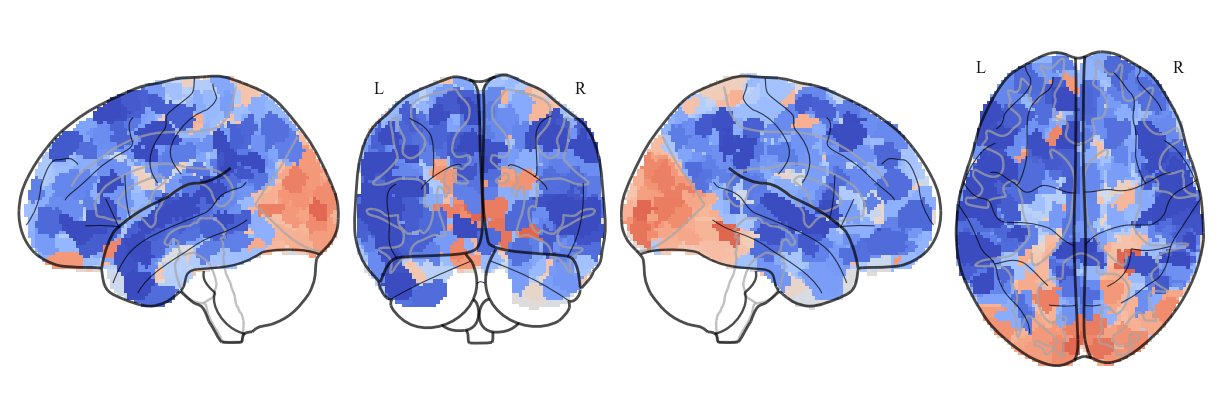

Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_audio_centered_attn_glass.pdf


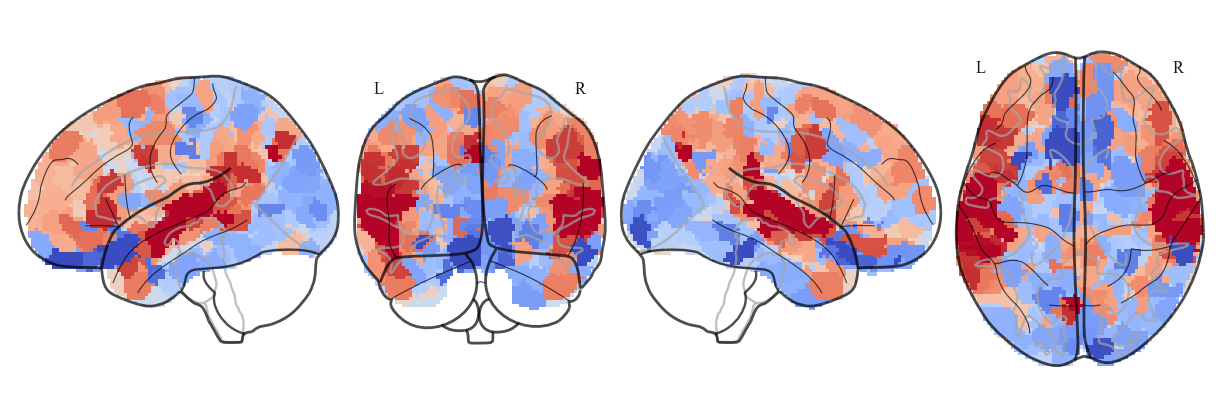

Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_text_centered_attn_glass.pdf


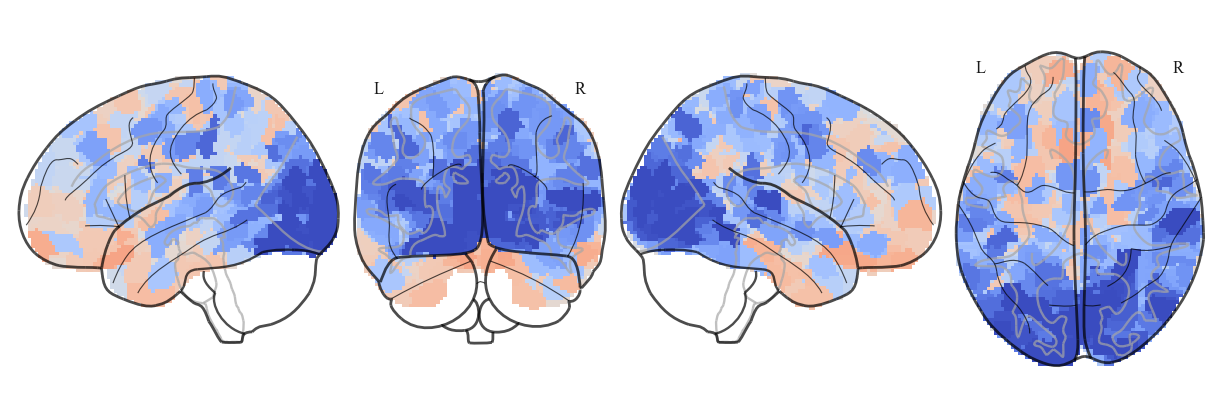

In [199]:
# centered normalized attention for each modality
for run in run_list:
    subject_id = run["subject_id"]
    df = run["parcel_df"].sort_values("parcel_id")

    for modality in run["modalities"]:
        out_file = FIGURE_ROOT / f"{file_label(run)}_{modality}_centered_attn_glass.pdf"
        print(f"Plotting {out_file.name}")
        plot_parcel_score(
            subject_id,
            df[f"relative_{modality}_centered"].to_numpy(),
            title=None, # f"{run_label(run)} {modality} relative centered attention",
            cmap="coolwarm",
            symmetric=True,
            threshold="auto",
            cbar_label=f"Relative {modality.capitalize()} Attn (%)",
            cbar_percent=True,
            out_file=out_file,
        )
    
    break


# 41 21
#29 15
#43 22

sub-05_videmae_wav2vec_deberta_parcels_04-18-2026-22-22


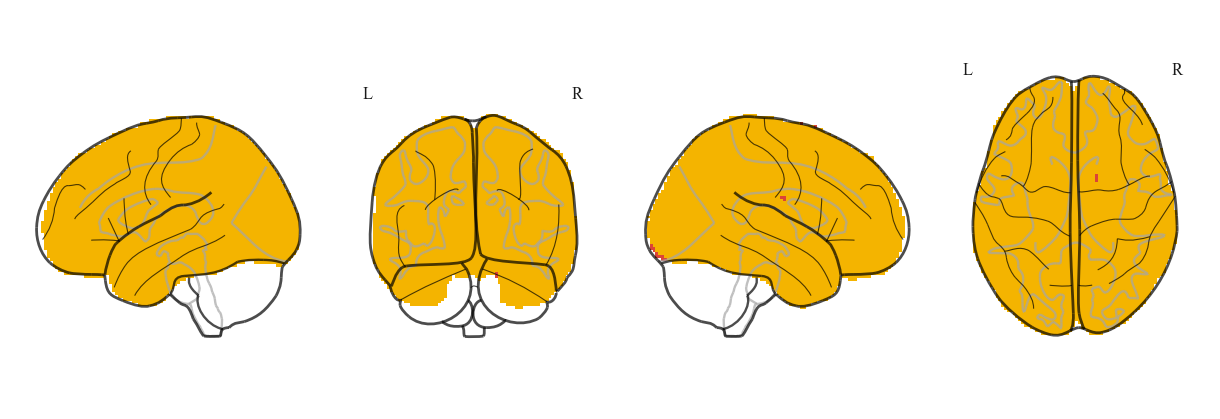

,winner_modality,num_parcels
0,text,973
1,audio,17
2,video,10


In [233]:
# modality preference
# run_key = DEFAULT_RUN_KEY
run_key = run_list[11]["run_key"]
run = runs[run_key]
print(run_key)

preference_display, modality_preference_df = plot_modality_preference_brain(
    run_key=run_key,
    min_margin=None,
    out_file=None,  # FIGURE_ROOT / f"{file_label(run)}_modality_preference_glass.pdf"
    title=None,
)

modality_preference_df[[
    "run_key",
    "subject_id",
    "run_name",
    "backbones",
    "readout",
    "preference_score_source",
    "parcel_id",
    "winner_code",
    "winner_modality",
    "winner_margin",
    "modality_entropy",
    "modality_selectivity",
]].to_csv(TABLE_ROOT / f"{file_label(run)}_modality_preference.csv", index=False)

display(
    modality_preference_df["winner_modality"]
    .value_counts()
    .rename_axis("winner_modality")
    .reset_index(name="num_parcels")
)


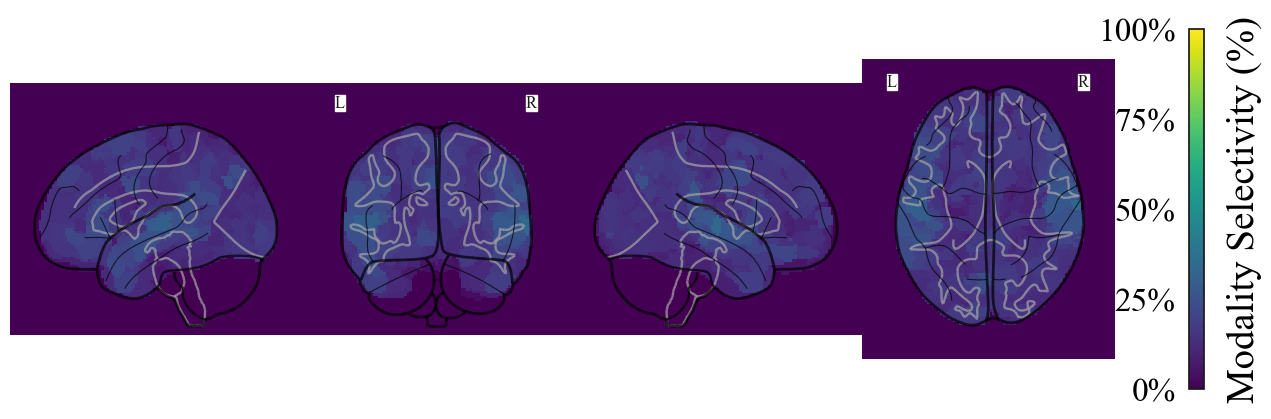

,winner_margin,modality_entropy,modality_selectivity
count,1000.000000,1000.000000,1000.000000
mean,0.305968,0.883811,0.116189
std,0.100273,0.044865,0.044865
min,0.005457,0.658834,0.005213
25%,0.240235,0.860758,0.087724
50%,0.311399,0.889756,0.110244
75%,0.373233,0.912276,0.139242
max,0.600559,0.994787,0.341166


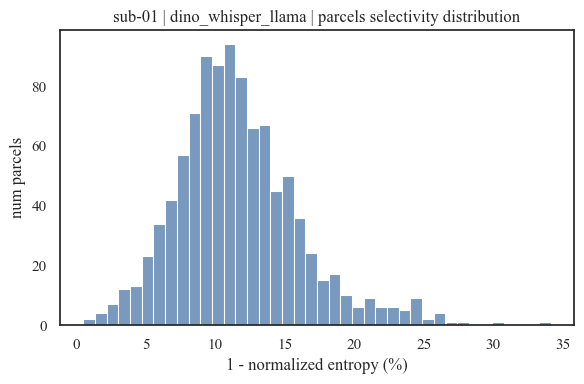

In [181]:
# modality selectivity
run_key = DEFAULT_RUN_KEY
run = runs[run_key]

selectivity_display, selectivity_hist, modality_selectivity_df = plot_modality_selectivity_summary(
    run_key=run_key,
    min_margin=None,
    out_file=None,  # FIGURE_ROOT / f"{file_label(run)}_modality_selectivity_glass.pdf"
    hist_file=None,  # FIGURE_ROOT / f"{file_label(run)}_modality_selectivity_hist.pdf"
    title=None,
)

modality_selectivity_df[[
    "run_key",
    "subject_id",
    "run_name",
    "backbones",
    "readout",
    "preference_score_source",
    "parcel_id",
    "winner_modality",
    "winner_margin",
    "modality_entropy",
    "modality_selectivity",
]].to_csv(TABLE_ROOT / f"{file_label(run)}_modality_selectivity.csv", index=False)

display(
    modality_selectivity_df[["winner_margin", "modality_entropy", "modality_selectivity"]]
    .describe()
)


sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08


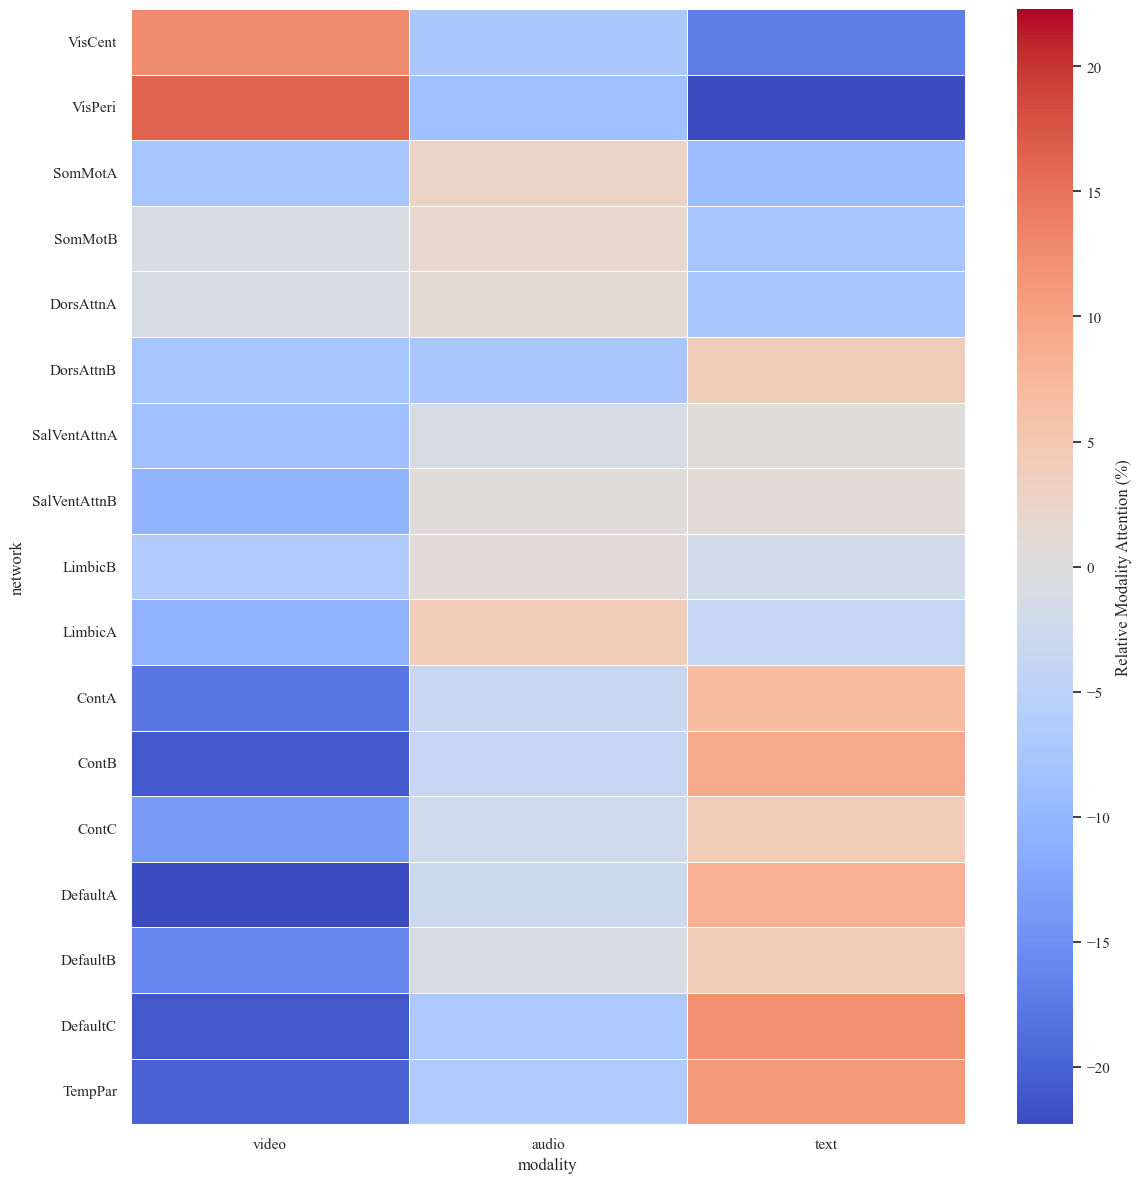

,run_key,subject_id,run_name,backbones,readout,network,modality,mean_relative_attention,median_relative_attention,std,sem,n_parcels,n_finite
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,video,12.432081,13.373862,7.477776,0.875207,73,73
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,audio,-7.285640,-7.539075,6.815859,0.797736,73,73
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,text,-17.152562,-15.967912,13.053768,1.527828,73,73
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,video,16.442123,16.786320,6.766581,0.866372,61,61
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,audio,-8.596034,-8.844043,6.267766,0.802505,61,61


In [229]:
# Schaefer-network overlap: continuous relative attention and categorical preference
# Change this run_key to inspect another subject/model/readout.
run_key = run_list[8]["run_key"]
run = runs[run_key]
print(run_key)

network_order = list(schaefer_labels)
modalities = list(run["modalities"])
relative_cols = [f"relative_{modality}_centered" for modality in modalities]

run_network_df = run["parcel_df"].merge(labels_df, on="parcel_id", how="left")
missing_network = int(run_network_df["network"].isna().sum())
if missing_network:
    raise ValueError(f"Missing Schaefer network labels for {missing_network} parcels.")

records = []
for network in network_order:
    parcel_mask = run_network_df["network"].to_numpy() == network
    n_parcels = int(parcel_mask.sum())

    for modality, col in zip(modalities, relative_cols):
        values = run_network_df.loc[parcel_mask, col].to_numpy(dtype=float)
        finite = np.isfinite(values)
        n_finite = int(finite.sum())
        records.append({
            "run_key": run["run_key"],
            "subject_id": run["subject_id"],
            "run_name": run["run_name"],
            "backbones": run["backbones"],
            "readout": run["readout"],
            "network": network,
            "modality": modality,
            "mean_relative_attention": np.nanmean(values) if n_finite else np.nan,
            "median_relative_attention": np.nanmedian(values) if n_finite else np.nan,
            "std": np.nanstd(values, ddof=1) if n_finite > 1 else np.nan,
            "sem": np.nanstd(values, ddof=1) / np.sqrt(n_finite) if n_finite > 1 else np.nan,
            "n_parcels": n_parcels,
            "n_finite": n_finite,
        })

network_overlap_df = pd.DataFrame(records)
network_overlap_df["network"] = pd.Categorical(network_overlap_df["network"], network_order, ordered=True)
network_overlap_df["modality"] = pd.Categorical(network_overlap_df["modality"], modalities, ordered=True)
network_overlap_df = network_overlap_df.sort_values(["network", "modality"])
network_overlap_df.to_csv(TABLE_ROOT / f"{file_label(run)}_network_relative_attention.csv", index=False)

heatmap_df = (
    network_overlap_df
    .pivot(index="network", columns="modality", values="mean_relative_attention")
    .loc[network_order, modalities]
)
heatmap_values = heatmap_df.to_numpy(dtype=float)
vmax = np.nanpercentile(np.abs(heatmap_values), 98)
vmax = 1.0 if not np.isfinite(vmax) or np.isclose(vmax, 0) else float(vmax)

fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=False,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Modality Attention (%)"},
    ax=ax,
)
# ax.set_xlabel("Modality")
# ax.set_ylabel("Schaefer network")
# ax.set_title(f"{run_label(run)} network relative attention")
fig.tight_layout()
plt.show()

display(network_overlap_df.head(5))


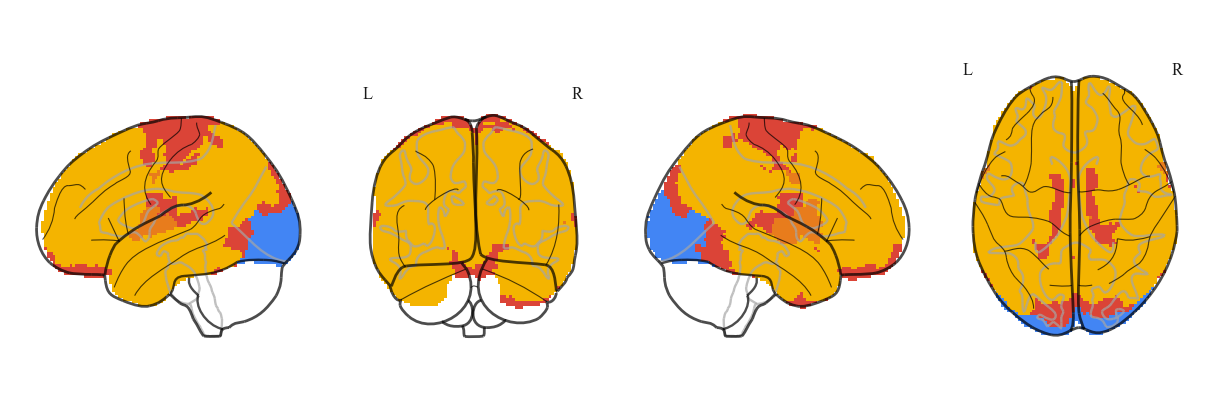

,run_key,subject_id,run_name,backbones,readout,network,positive_modalities,network_color,video_mean_relative_attention,audio_mean_relative_attention,text_mean_relative_attention
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,video,#4285f4,12.432081,-7.285640,-17.152562
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,video,#4285f4,16.442123,-8.596034,-22.832057
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SomMotA,audio,#db4437,-7.676015,2.670393,-9.151707
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SomMotB,audio,#db4437,-0.840772,1.742451,-7.686915
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,DorsAttnA,audio,#db4437,-1.198573,1.250215,-7.371233
5,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,DorsAttnB,text,#f4b400,-7.904793,-7.540189,3.991104
6,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SalVentAttnA,text,#f4b400,-8.747277,-1.154369,0.432688
7,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SalVentAttnB,audio+text,#e87c1c,-10.507162,0.280940,0.955111
8,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,LimbicB,audio,#db4437,-6.597268,0.959695,-1.766166
9,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,LimbicA,audio,#db4437,-10.931061,4.073697,-3.712468


In [230]:
# Atlas plot: blend modality colors for networks with positive heatmap values
# This cell uses network_overlap_df from the previous Schaefer-network heatmap cell.
MODALITY_COLORS = {
    "video": "#4285F4",
    "audio": "#DB4437",
    "text": "#F4B400",
}

if "network_overlap_df" not in globals():
    raise NameError("Run the Schaefer-network overlap heatmap cell before this atlas projection cell.")

modality_rgb = {
    modality: np.asarray(plt.matplotlib.colors.to_rgb(MODALITY_COLORS[modality]), dtype=float)
    for modality in modalities
}
neutral_network_color = "#D0D0D0"

network_color_records = []
network_code_by_name = {network: code for code, network in enumerate(network_order)}
network_colors = {}
network_labels_for_legend = []

for network in network_order:
    row = heatmap_df.loc[network, modalities].astype(float)
    positive_modalities = [modality for modality in modalities if np.isfinite(row[modality]) and row[modality] > 0]

    if positive_modalities:
        # Equal blend across positive modalities, matching the heatmap-sign rule.
        rgb = np.mean([modality_rgb[modality] for modality in positive_modalities], axis=0)
        color = plt.matplotlib.colors.to_hex(np.clip(rgb, 0, 1))
        blend_label = "+".join(positive_modalities)
    else:
        color = neutral_network_color
        blend_label = "none positive"

    code = network_code_by_name[network]
    network_colors[code] = color
    network_labels_for_legend.append((code, f"{network}: {blend_label}"))
    network_color_records.append({
        "run_key": run["run_key"],
        "subject_id": run["subject_id"],
        "run_name": run["run_name"],
        "backbones": run["backbones"],
        "readout": run["readout"],
        "network": network,
        "positive_modalities": blend_label,
        "network_color": color,
        **{f"{modality}_mean_relative_attention": float(row[modality]) for modality in modalities},
    })

network_color_df = pd.DataFrame(network_color_records)
network_color_df.to_csv(TABLE_ROOT / f"{file_label(run)}_network_positive_modality_blend_colors.csv", index=False)

parcel_network_codes = np.full(1000, np.nan, dtype=np.float32)
for _, row in labels_df.iterrows():
    parcel_id = int(row["parcel_id"])
    network = row["network"]
    if network in network_code_by_name:
        parcel_network_codes[parcel_id - 1] = float(network_code_by_name[network])

network_blend_display = plot_categorical_parcel_labels(
    run["subject_id"],
    parcel_network_codes,
    code_labels=network_labels_for_legend,
    code_colors=network_colors,
    title=None,  # f"{run_label(run)} positive network modality blend"
    out_file=None,  # FIGURE_ROOT / f"{file_label(run)}_network_positive_modality_blend_glass.pdf"
)

display(network_color_df)


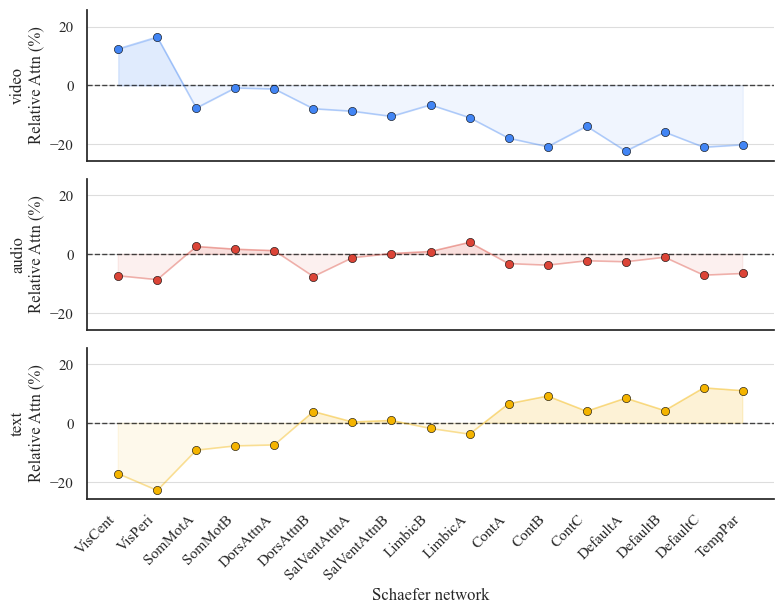

In [231]:
# Modality-specific network profiles: row-aligned trend plots
# This cell uses network_overlap_df from the Schaefer-network overlap heatmap cell.

if "network_overlap_df" not in globals():
    raise NameError("Run the Schaefer-network overlap heatmap cell before this profile plot cell.")

profile_df = (
    network_overlap_df
    .pivot(index="network", columns="modality", values="mean_relative_attention")
    .loc[network_order, modalities]
)
x = np.arange(len(network_order), dtype=float)

fig, axes = plt.subplots(
    nrows=len(modalities),
    ncols=1,
    figsize=(max(8.0, 0.42 * len(network_order)), 2.1 * len(modalities)),
    sharex=True,
    sharey=True,
    facecolor="white",
)
axes = np.atleast_1d(axes)

finite_values = profile_df.to_numpy(dtype=float)
y_lim = np.nanpercentile(np.abs(finite_values), 98)
y_lim = 1.0 if not np.isfinite(y_lim) or np.isclose(y_lim, 0) else float(y_lim)
y_lim *= 1.15

for ax, modality in zip(axes, modalities):
    y = profile_df[modality].to_numpy(dtype=float)
    finite = np.isfinite(y)
    color = MODALITY_COLORS[modality]

    ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.plot(x[finite], y[finite], color=color, alpha=0.35, linewidth=1.2)
    ax.scatter(x[finite], y[finite], color=color, edgecolor="black", linewidth=0.4, s=35, zorder=3)

    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y >= 0), color=color, alpha=0.16, interpolate=True)
    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y < 0), color=color, alpha=0.08, interpolate=True)
    ax.set_ylabel(f"{modality}\nRelative Attn (%)")
    ax.set_ylim(-y_lim, y_lim)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(network_order, rotation=45, ha="right")
axes[-1].set_xlabel("Schaefer network")
# fig.suptitle(f"{run_label(run)} modality-specific network profiles", y=1.02)
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_modality_network_profiles.pdf",
    dpi=250,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()


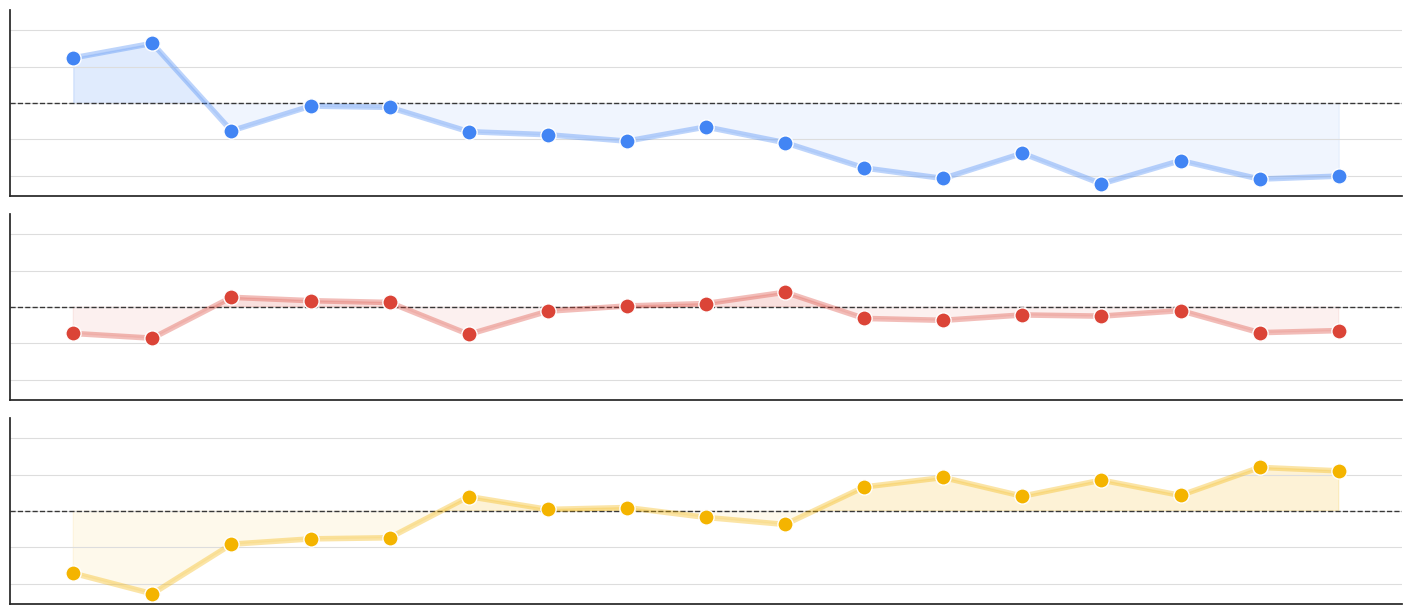

In [232]:
# Modality-specific network profiles: row-aligned trend plots
# Requires network_overlap_df from the Schaefer-network overlap heatmap cell.

if "network_overlap_df" not in globals():
    raise NameError(
        "Run the Schaefer-network overlap heatmap cell before this profile plot cell."
    )

profile_df = (
    network_overlap_df
    .pivot(index="network", columns="modality", values="mean_relative_attention")
    .loc[network_order, modalities]
)

x = np.arange(len(network_order), dtype=float)

fig, axes = plt.subplots(
    nrows=len(modalities),
    ncols=1,
    figsize=(0.84 * len(network_order), 2.1 * len(modalities)),
    sharex=True,
    sharey=True,
    facecolor="white",
)

axes = np.atleast_1d(axes)

finite_values = profile_df.to_numpy(dtype=float)
y_lim = np.nanpercentile(np.abs(finite_values), 98)
y_lim = 1.0 if not np.isfinite(y_lim) or np.isclose(y_lim, 0) else float(y_lim)
y_lim *= 1.15

for ax, modality in zip(axes, modalities):
    y = profile_df[modality].to_numpy(dtype=float)
    finite = np.isfinite(y)
    color = MODALITY_COLORS[modality]

    # Baseline at zero
    ax.axhline(
        0,
        color="black",
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )

    # Profile line and points
    ax.plot(
        x[finite],
        y[finite],
        color=color,
        alpha=0.35,
        linewidth=4,
        zorder=2,
    )

    ax.scatter(
        x[finite],
        y[finite],
        color=color,
        edgecolor="white",
        linewidth=1,
        s=120,
        zorder=3,
    )

    # Positive / negative filled area relative to baseline
    ax.fill_between(
        x,
        0,
        y,
        where=np.isfinite(y) & (y >= 0),
        color=color,
        alpha=0.16,
        interpolate=True,
        zorder=0,
    )

    ax.fill_between(
        x,
        0,
        y,
        where=np.isfinite(y) & (y < 0),
        color=color,
        alpha=0.08,
        interpolate=True,
        zorder=0,
    )

    ax.set_ylim(-y_lim, y_lim)

    # Keep horizontal guide lines, but remove all ticks/labels
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.grid(axis="x", visible=False)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )

    # Remove spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

# Remove x ticks explicitly from shared bottom axis
axes[-1].set_xticks([])
axes[-1].set_xlabel("")

fig.tight_layout()

fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_modality_network_profiles.pdf",
    dpi=250,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()